In [2]:
#Importing the Libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
import pandas as pd

# Import dataset
dataset_train = pd.read_csv('Google-Stock-Price-Train.csv')

# Select training set (Open price column)
training_set = dataset_train.iloc[:, 1:2].values

In [18]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)

In [28]:
timesteps = 5   # reduce from 60

X_train = []
y_train = []

for i in range(timesteps, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-timesteps:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

In [29]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

In [30]:
# Part 2 Building the RNN

In [32]:
#Importing the Keras libraries and packages

from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Input

In [40]:
regressor = Sequential()

In [51]:
from keras.models import Sequential
from keras.layers import LSTM, Dropout

# Reinitialize model (IMPORTANT)
regressor = Sequential()

# First LSTM layer (define input_shape here ONLY)
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(60, 1)))
regressor.add(Dropout(0.2))

In [52]:
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense

# Initialize model
regressor = Sequential()

# First LSTM layer (IMPORTANT)
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

# Second LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

In [53]:
# Adding the third LSTM layer and some Dropout regularisation 
regressor.add(LSTM(units = 50, return_sequences = True)) 
regressor.add(Dropout(0.2))

In [54]:
# Adding the fourth LSTM layer and some Dropout regularisation 
regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.2))

In [55]:
# Adding the output layer 
regressor.add(Dense (units = 1))

In [56]:
#Compiling the RNN

regressor.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [57]:
#Fitting the RNN to the Training set

regressor.fit(X_train, y_train, epochs = 100, batch_size = 32)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step - loss: 0.3774
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.3620
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.3462
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.3314
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 0.3120
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - loss: 0.2971
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - loss: 0.2749
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - loss: 0.2557
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 0.2315
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - loss: 0.2030
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 0.1792
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.1472
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.1192
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.0930
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0750
Epoch

In [75]:
import pandas as pd

dataset_train = pd.read_csv(r"C:\Users\darsh\Downloads\Google-Stock-Price-Train.csv")
real_stock_price = dataset_train.iloc[:, 1:2].values

In [76]:
# Combine train + test
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis=0)

# IMPORTANT: use smaller timesteps (since your data is small)
timesteps = 5

# Prepare inputs
inputs = dataset_total[len(dataset_total) - len(dataset_test) - timesteps:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

# Create X_test
X_test = []
for i in range(timesteps, len(inputs)):
    X_test.append(inputs[i-timesteps:i, 0])

X_test = np.array(X_test)

# Reshape for LSTM
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Prediction
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


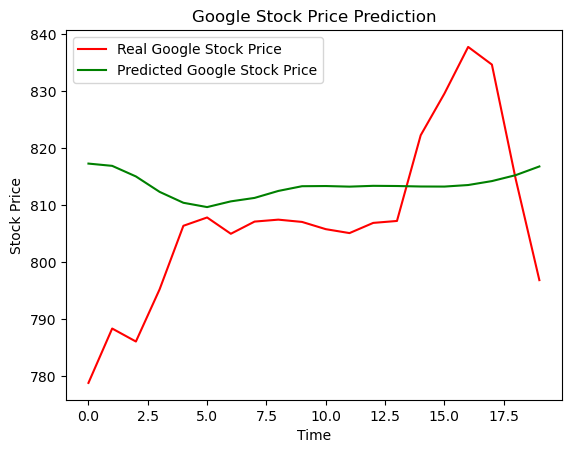

In [77]:
import matplotlib.pyplot as plt

plt.plot(real_stock_price, color='red', label='Real Google Stock Price')
plt.plot(predicted_stock_price, color='green', label='Predicted Google Stock Price')

plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')

plt.legend()
plt.show()